In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style="darkgrid")

In [76]:
PATH = "../Results/alns_qlearning_metrics.csv"

with open(PATH, 'r') as f:
    lineas = f.readlines()
    
historial_str, q_dest_str, q_rep_str = "", "", ""
seccion_actual = 0 # 0: Historial, 1: Matriz Destrucción, 2: Matriz Reparación

for linea in lineas:
    if linea.startswith('# MATRIZ_Q_DESTRUCCION'):
        seccion_actual = 1
        continue
    elif linea.startswith('# MATRIZ_Q_REPARACION'):
        seccion_actual = 2
        continue
    elif linea.strip() == '':
        continue

    if seccion_actual == 0:
        historial_str += linea
    elif seccion_actual == 1:
        q_dest_str += linea
    elif seccion_actual == 2:
        q_rep_str += linea
        
df = pd.read_csv(io.StringIO(historial_str))
df_q_dest = pd.read_csv(io.StringIO(q_dest_str), index_col='Estado')
df_q_rep = pd.read_csv(io.StringIO(q_rep_str), index_col='Estado')

best_veh = df['best_veh'].idxmin()
best_veh_iter = df.loc[best_veh, 'iter']
df['best_global_cost'] = (df['best_veh'] * 10000.0) + df['best_dist']
best_index = df['best_global_cost'].idxmin()
best_iter = df.loc[best_index, 'iter']

print(f"Historial cargado: {len(df)} iteraciones.")
print(f"Matriz Q-Destrucción cargada: {df_q_dest.shape}")
print(f"Matriz Q-Reparación cargada: {df_q_rep.shape}")
print(f"Óptimo encontrado en la iteración: {df.loc[best_index, 'iter']}")

Historial cargado: 25000 iteraciones.
Matriz Q-Destrucción cargada: (3, 4)
Matriz Q-Reparación cargada: (3, 4)
Óptimo encontrado en la iteración: 24505


# Comportamiento del ALNS + Q-learning
---

### Convergencia de la función objetivo $f_1$

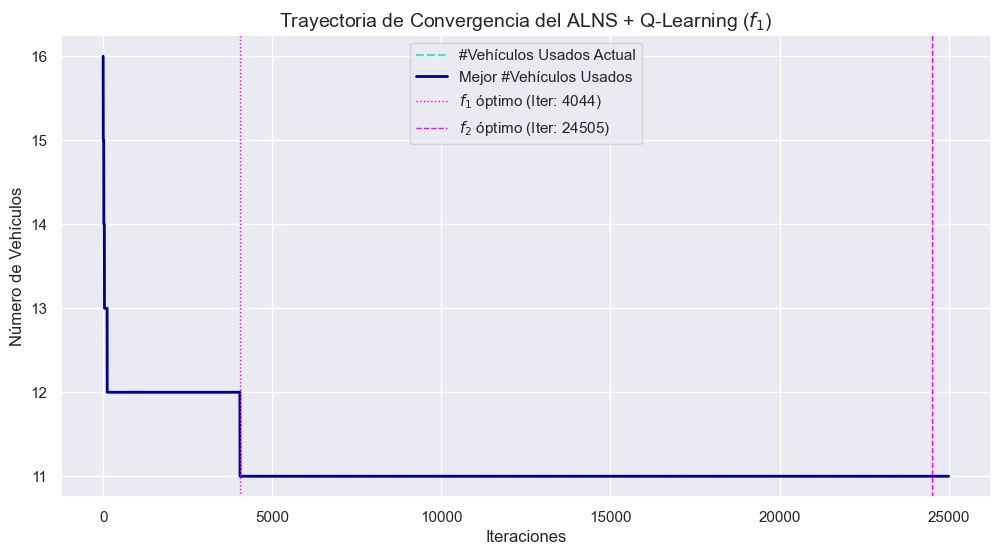

In [77]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='iter', y='curr_veh', color='turquoise', alpha=1, label='#Vehículos Usados Actual', linestyle='--')
sns.lineplot(data=df, x='iter', y='best_veh', color='darkblue', linewidth=2, label='Mejor #Vehículos Usados')

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Trayectoria de Convergencia del ALNS + Q-Learning ($f_1$)', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Número de Vehículos')
plt.legend()
plt.show()

### Convergencia de la función objetivo $f_2$

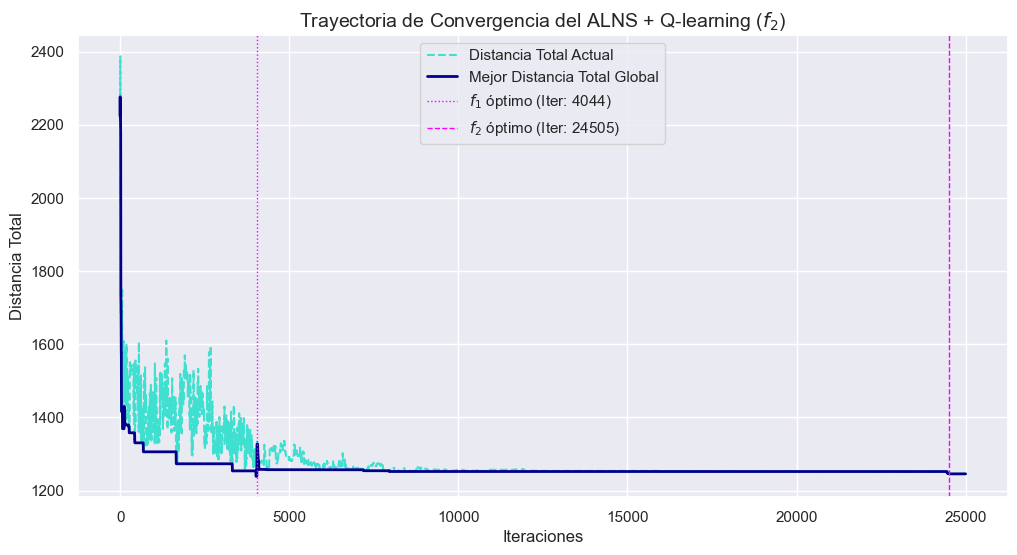

In [78]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='iter', y='curr_dist', color='turquoise', alpha=1, label='Distancia Total Actual', linestyle='--')
sns.lineplot(data=df, x='iter', y='best_dist', color='darkblue', linewidth=2, label='Mejor Distancia Total Global')

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Trayectoria de Convergencia del ALNS + Q-learning ($f_2$)', fontsize=14)
plt.xlabel('Iteraciones')
plt.ylabel('Distancia Total')
plt.legend()
plt.show()

### Evolución de selección de operadores

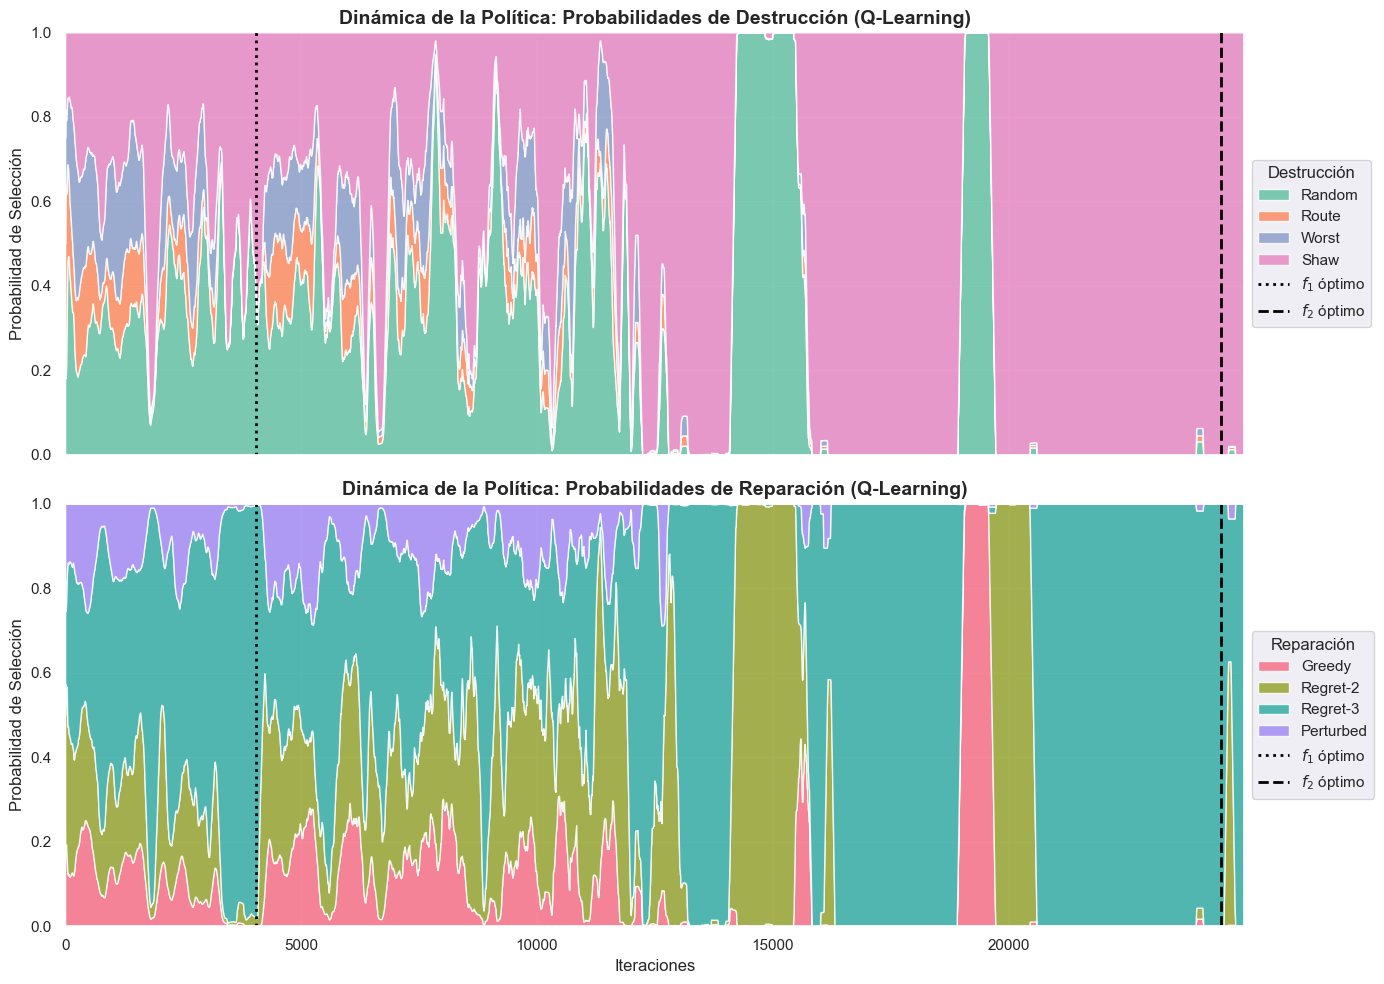

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definimos la ventana de suavizado. Un valor de 100-200 es ideal para miles de iteraciones.
VENTANA = 150 

# 1. Configuración de Destrucción
d_cols = [c for c in df.columns if 'd_weight' in c]
d_names = ['Random', 'Route', 'Worst', 'Shaw']
d_smoothed = [df[col].rolling(window=VENTANA, min_periods=1).mean() for col in d_cols]

# 2. Configuración de Reparación
r_cols = [c for c in df.columns if 'r_weight' in c]
r_names = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']
r_smoothed = [df[col].rolling(window=VENTANA, min_periods=1).mean() for col in r_cols]

# Creamos una figura con dos subgráficos apilados verticalmente
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Gráfico Superior: Operadores de Destrucción ---
ax1.stackplot(df['iter'], d_smoothed, labels=d_names, alpha=0.85, colors=sns.color_palette("Set2", 4))
ax1.axvline(x=best_veh_iter, color='black', linestyle=':', linewidth=2, label=f'$f_1$ óptimo')
ax1.axvline(x=best_iter, color='black', linestyle='--', linewidth=2, label=f'$f_2$ óptimo')

ax1.set_title('Dinámica de la Política: Probabilidades de Destrucción (Q-Learning)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Probabilidad de Selección', fontsize=12)
ax1.set_ylim(0, 1.0)
ax1.margins(x=0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Destrucción")

# --- Gráfico Inferior: Operadores de Reparación ---
ax2.stackplot(df['iter'], r_smoothed, labels=r_names, alpha=0.85, colors=sns.color_palette("husl", 4))
ax2.axvline(x=best_veh_iter, color='black', linestyle=':', linewidth=2, label=f'$f_1$ óptimo')
ax2.axvline(x=best_iter, color='black', linestyle='--', linewidth=2, label=f'$f_2$ óptimo')

ax2.set_title('Dinámica de la Política: Probabilidades de Reparación (Q-Learning)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iteraciones', fontsize=12)
ax2.set_ylabel('Probabilidad de Selección', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.margins(x=0)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Reparación")

plt.tight_layout()
plt.show()

### Evolución de selección de operadores de destrucción

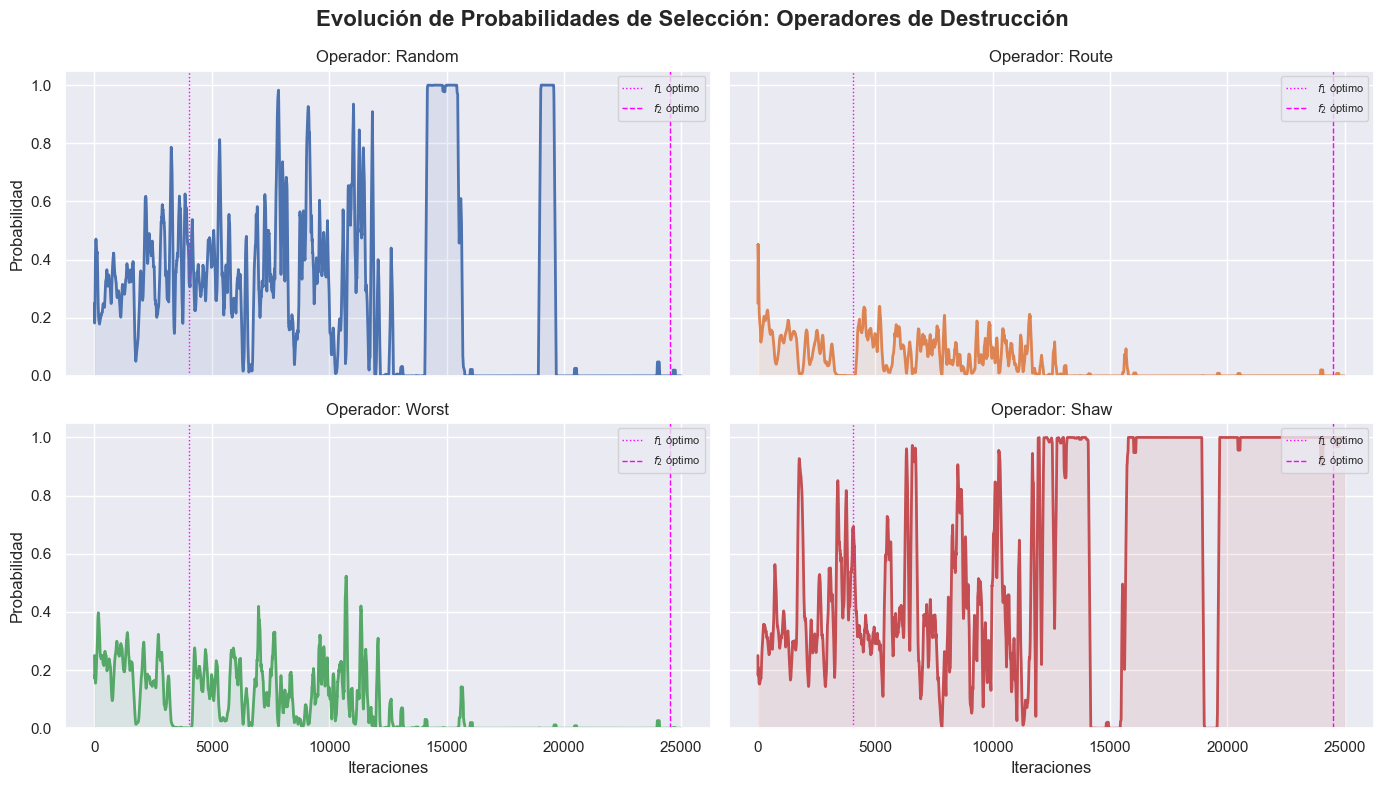

In [80]:
# Extracción de columnas de destrucción
d_cols = [c for c in df.columns if 'd_weight' in c]
d_names = ['Random', 'Route', 'Worst', 'Shaw']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle('Evolución de Probabilidades de Selección: Operadores de Destrucción', fontsize=16, fontweight='bold')

axes = axes.flatten()
colores = sns.color_palette()

window_size = 100 
for i, (col, name) in enumerate(zip(d_cols, d_names)):
    smoothed_data = df[col].rolling(window=window_size, min_periods=1).mean()
    sns.lineplot(x=df['iter'], y=smoothed_data, ax=axes[i], color=colores[i], linewidth=2)
    axes[i].set_title(f'Operador: {name}')
    axes[i].set_ylabel('Probabilidad')
    axes[i].set_ylim(0, 1.05) 
    axes[i].fill_between(df['iter'], smoothed_data, alpha=0.1, color=colores[i])
    axes[i].axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo')
    axes[i].axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo')
    axes[i].legend(loc='upper right', fontsize=8)

axes[2].set_xlabel('Iteraciones')
axes[3].set_xlabel('Iteraciones')

plt.tight_layout()
plt.show()

### Evolución de selección de operadores de inserción

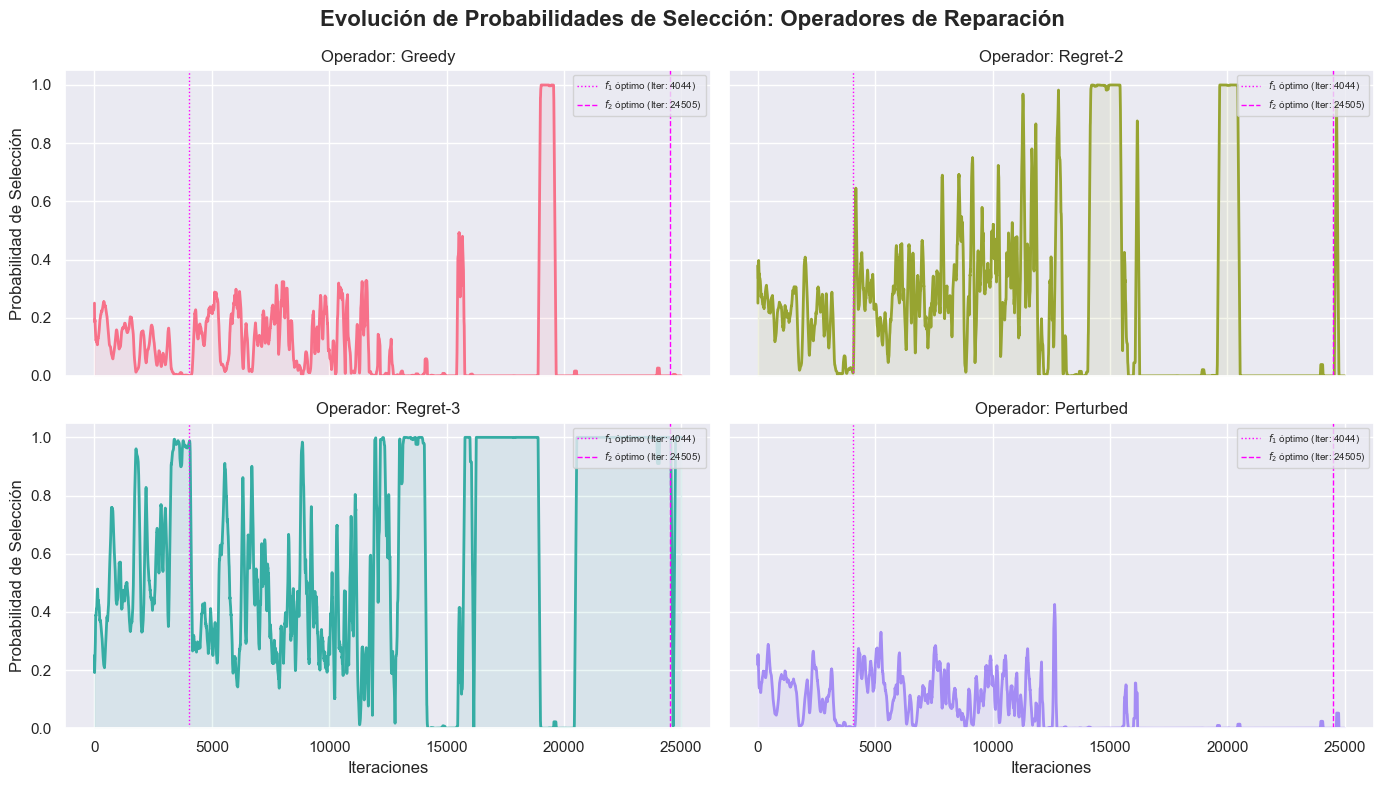

In [81]:
# Extracción de columnas de reparación
r_cols = [c for c in df.columns if 'r_weight' in c]
r_names = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
# Modificación: Actualización del título para reflejar probabilidades
fig.suptitle('Evolución de Probabilidades de Selección: Operadores de Reparación', fontsize=16, fontweight='bold')

axes = axes.flatten()
colores_repair = sns.color_palette("husl", 4)

# Definimos la ventana de suavizado (puedes ajustar este valor si tienes muchas o pocas iteraciones)
window_size = 100 

for i, (col, name) in enumerate(zip(r_cols, r_names)):
    # 1. Aplicamos la media móvil (rolling) para suavizar la curva de probabilidades
    smoothed_data = df[col].rolling(window=window_size, min_periods=1).mean()
    
    # 2. Graficamos 'smoothed_data' en lugar de la columna en crudo
    sns.lineplot(x=df['iter'], y=smoothed_data, ax=axes[i], color=colores_repair[i], linewidth=2)
    axes[i].set_title(f'Operador: {name}')
    
    # 3. Modificación: El eje Y refleja probabilidades y se fija en el rango [0, 1]
    axes[i].set_ylabel('Probabilidad de Selección')
    axes[i].set_ylim(0, 1.05) 
    
    # 4. Aplicamos el sombreado también sobre los datos suavizados
    axes[i].fill_between(df['iter'], smoothed_data, alpha=0.1, color=colores_repair[i])
    
    axes[i].axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
    axes[i].axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')
    
    axes[i].legend(loc='upper right', fontsize=7)

axes[2].set_xlabel('Iteraciones')
axes[3].set_xlabel('Iteraciones')

plt.tight_layout()
plt.show()

### Sinergía de Operadores

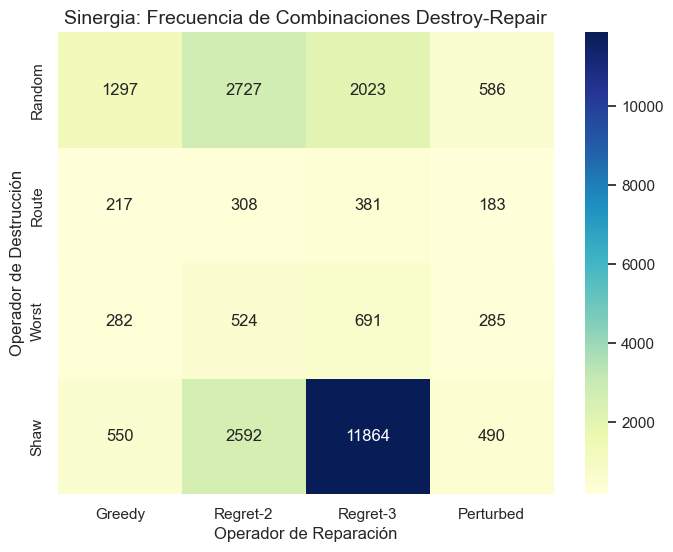

In [82]:
synergy_matrix = pd.crosstab(df['d_op'], df['r_op'])

synergy_matrix = synergy_matrix.reindex(index=[0, 1, 2, 3], columns=[0, 1, 2, 3], fill_value=0)

synergy_matrix.index = ['Random', 'Route', 'Worst', 'Shaw']
synergy_matrix.columns = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']

plt.figure(figsize=(8, 6))
sns.heatmap(synergy_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Sinergia: Frecuencia de Combinaciones Destroy-Repair', fontsize=14)
plt.xlabel('Operador de Reparación')
plt.ylabel('Operador de Destrucción')
plt.show()

### Perfil Termodinámico

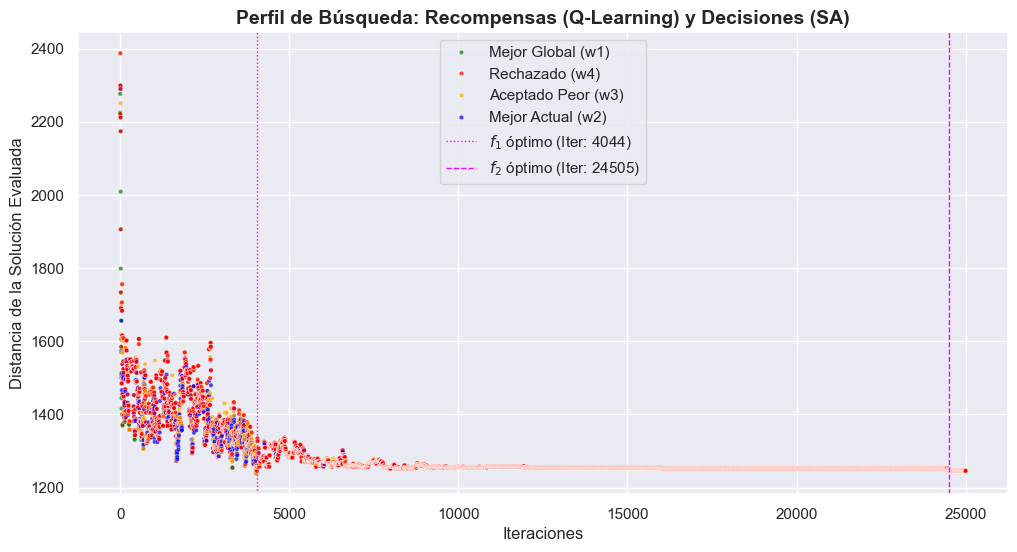

In [83]:
plt.figure(figsize=(12, 6))

# Modificación: Cambiamos 'score' por 'reward', que es el nombre de la columna exportada en C++
# IMPORTANTE: Verifica que 33.0, 13.0, 9.0 y 0.0 sean exactamente los valores w1, w2, w3 y w4 de tu C++
reward_map = {33.0: 'Mejor Global (w1)', 13.0: 'Mejor Actual (w2)', 9.0: 'Aceptado Peor (w3)', 0.0: 'Rechazado (w4)'}
df['reward_label'] = df['reward'].map(reward_map)

# Buena práctica: por si algún valor no mapea bien (por problemas de decimales)
df['reward_label'] = df['reward_label'].fillna('Otro / Desconocido')

# Paleta actualizada para incluir el caso 'Otro'
paleta_recompensas = {
    'Mejor Global (w1)': 'green', 
    'Mejor Actual (w2)': 'blue', 
    'Aceptado Peor (w3)': 'orange', 
    'Rechazado (w4)': 'red',
    'Otro / Desconocido': 'gray'
}

# Usamos 'reward_label' en lugar de 'score_label'
sns.scatterplot(data=df, x='iter', y='curr_dist', hue='reward_label', 
                palette=paleta_recompensas, s=10, alpha=0.7)

plt.axvline(x=best_veh_iter, color='magenta', linestyle=':', linewidth=1, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='magenta', linestyle='--', linewidth=1, label=f'$f_2$ óptimo (Iter: {best_iter})')

# Modificación: Título ajustado a la dualidad Q-Learning + SA
plt.title('Perfil de Búsqueda: Recompensas (Q-Learning) y Decisiones (SA)', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones')
plt.ylabel('Distancia de la Solución Evaluada')
plt.legend()
plt.show()

### Timeline de Estados del Agente

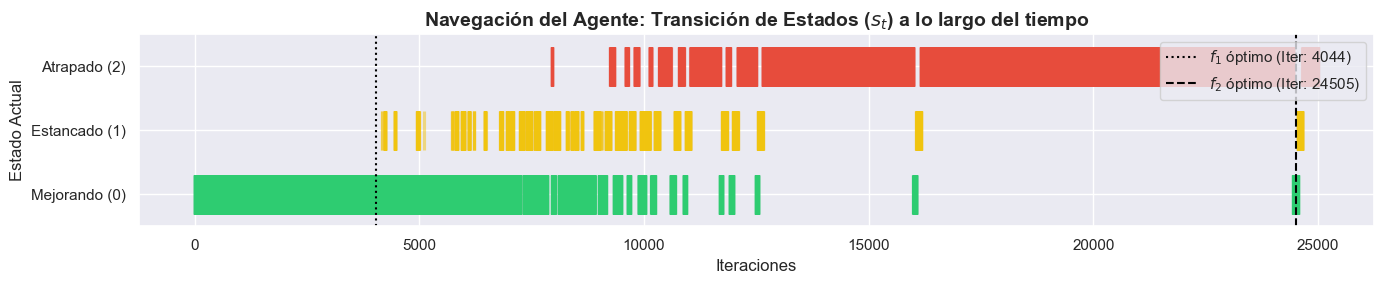

In [84]:
plt.figure(figsize=(14, 3))

mapa_estados = {0: 'Mejorando (0)', 1: 'Estancado (1)', 2: 'Atrapado (2)'}
df['state_label'] = df['state'].map(mapa_estados)

sns.scatterplot(data=df, x='iter', y='state_label', hue='state_label', 
                palette={ 'Mejorando (0)':'#2ecc71', 'Estancado (1)':'#f1c40f', 'Atrapado (2)':'#e74c3c'},
                marker='|', s=800, alpha=0.5, legend=False)

plt.axvline(x=best_veh_iter, color='black', linestyle=':', linewidth=1.5, label=f'$f_1$ óptimo (Iter: {best_veh_iter})')
plt.axvline(x=best_iter, color='black', linestyle='--', linewidth=1.5, label=f'$f_2$ óptimo (Iter: {best_iter})')

plt.title('Navegación del Agente: Transición de Estados ($s_t$) a lo largo del tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones')
plt.ylabel('Estado Actual')
plt.yticks([0, 1, 2], ['Mejorando (0)', 'Estancado (1)', 'Atrapado (2)'])
plt.ylim(-0.5, 2.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Mapa Térmico de la $Q$-Matrix

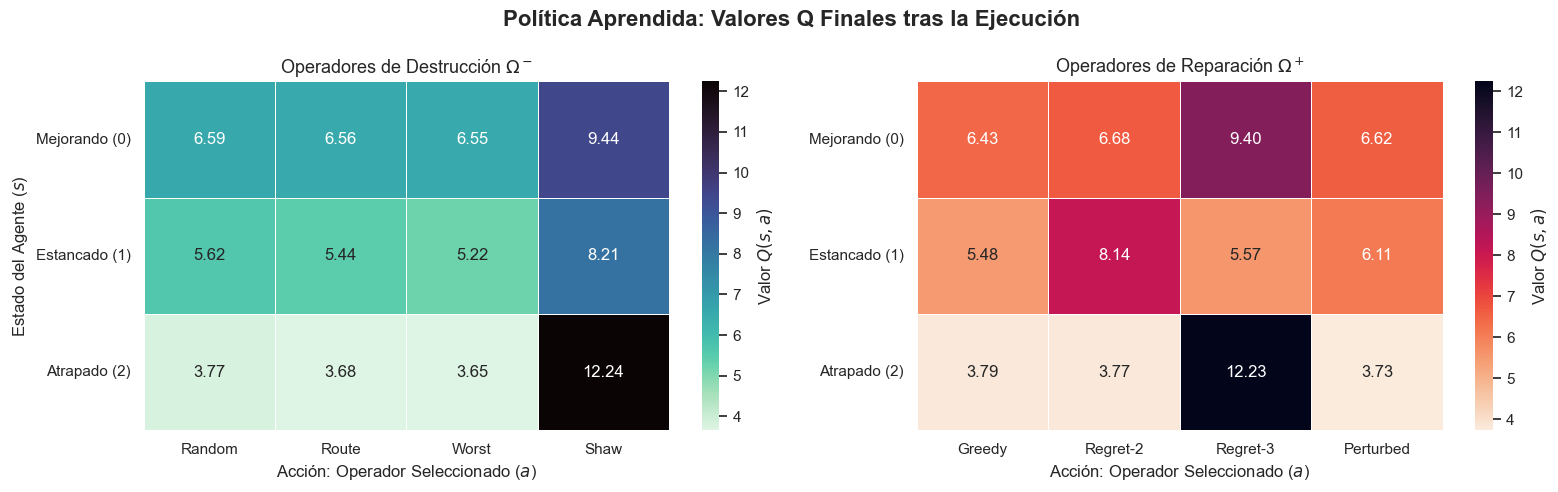

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Política Aprendida: Valores Q Finales tras la Ejecución', fontsize=16, fontweight='bold')

nombres_y = ['Mejorando (0)', 'Estancado (1)', 'Atrapado (2)']

sns.heatmap(df_q_dest, annot=True, fmt=".2f", cmap="mako_r", 
            cbar_kws={'label': 'Valor $Q(s, a)$'}, ax=axes[0], linewidths=.5)
axes[0].set_title('Operadores de Destrucción $\Omega^-$', fontsize=13)
axes[0].set_ylabel('Estado del Agente ($s$)')
axes[0].set_xlabel('Acción: Operador Seleccionado ($a$)')
axes[0].set_yticklabels(nombres_y, rotation=0)

sns.heatmap(df_q_rep, annot=True, fmt=".2f", cmap="rocket_r", 
            cbar_kws={'label': 'Valor $Q(s, a)$'}, ax=axes[1], linewidths=.5)
axes[1].set_title('Operadores de Reparación $\Omega^+$', fontsize=13)
axes[1].set_ylabel('')
axes[1].set_xlabel('Acción: Operador Seleccionado ($a$)')
axes[1].set_yticklabels(nombres_y, rotation=0)

plt.tight_layout()
plt.show()